<a href="https://colab.research.google.com/github/mireillejb/FallDetectionSys/blob/main/kaggle_anticipative_casia_b_hrnet_finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1 — Import Libraries
# ============================================================
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import classification_report, f1_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu')
print("✅ Libraries importées")
print(f"   PyTorch : {torch.__version__}")
print(f"   Device  : {DEVICE}")

✅ Libraries importées
   PyTorch : 2.9.0+cu126
   Device  : cuda


In [ ]:
# ============================================================
# CELL 2 — Download CASIA-B HRNet
# ============================================================
!pip install kagglehub --quiet
import kagglehub

path = kagglehub.dataset_download(
    "mireillejabbour/casia-b-hrnet")
print(f"✅ CASIA-B path: {path}")

✅ CASIA-B path: /kaggle/input/datasets/mireillejabbour/casia-b-hrnet


In [ ]:
# ============================================================
# CELL 3 — Load CASIA-B HRNet
# ============================================================
from pathlib import Path
from collections import Counter
import pickle, numpy as np
from tqdm import tqdm

DATA_ROOT = Path(path) / "CASIA-B_HRNet"

SKELETON_PAIRS = [
    (0,1),(0,2),(1,3),(2,4),
    (5,6),(5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16)
]

def load_casia_b(root_path, conditions=None):
    root      = Path(root_path)
    pkl_files = sorted(root.rglob("*.pkl"))
    sequences = []
    metadata  = []
    skipped   = 0

    for fp in tqdm(pkl_files, desc="Loading CASIA-B"):
        parts = fp.relative_to(root).parts
        if len(parts) < 4:
            skipped += 1
            continue
        subject   = parts[0]
        cond_seq  = parts[1]
        view      = parts[2]
        condition = cond_seq.split('-')[0]
        sequence  = cond_seq.split('-')[1]

        if conditions and condition not in conditions:
            continue
        try:
            with open(fp, 'rb') as f:
                data = pickle.load(f)
            if not isinstance(data, np.ndarray):
                data = np.array(data, dtype=np.float32)
            if data.ndim != 3 or data.shape[1] != 17:
                skipped += 1
                continue
            if len(data) < 25:
                skipped += 1
                continue
            sequences.append(data.astype(np.float32))
            metadata.append({
                'subject'  : subject,
                'condition': condition,
                'sequence' : sequence,
                'view'     : view,
                'frames'   : len(data)
            })
        except Exception:
            skipped += 1

    print(f"\n✅ Chargées : {len(sequences)} séquences")
    print(f"   Ignorées : {skipped}")
    print(f"   Shape ex.: {sequences[0].shape}")
    return sequences, metadata

sequences, metadata = load_casia_b(
    DATA_ROOT, conditions=['nm'])

Loading CASIA-B: 100%|██████████| 13637/13637 [00:42<00:00, 323.11it/s]


✅ Chargées : 8171 séquences
   Ignorées : 10
   Shape ex.: (96, 17, 3)


In [ ]:
# ============================================================
# CELL 4 — Feature Extraction + Build Windows (CASIA-B)
# ============================================================
WINDOW_SIZE   = 30
PREDICT_STEPS = 8
STRIDE        = 5
FPS           = 16

def extract_features(kp_seq):
    """(T,17,3) → (T,34) normalisé hip-centered"""
    xy         = kp_seq[:, :, :2].copy().astype(np.float32)
    hip_center = (xy[:, 11, :] + xy[:, 12, :]) / 2.0
    rel        = xy - hip_center[:, np.newaxis, :]
    torso_h    = np.linalg.norm(
        xy[:, 0, :] - hip_center, axis=1)
    torso_h    = np.maximum(torso_h, 1e-6)
    rel        = rel / torso_h[:, np.newaxis, np.newaxis]
    return rel.reshape(len(kp_seq), -1)

def build_windows(sequences, window_size=WINDOW_SIZE,
                  predict_steps=PREDICT_STEPS,
                  stride=STRIDE):
    X_list, Y_list = [], []
    for seq in tqdm(sequences, desc="Building windows"):
        feats   = extract_features(seq)
        T       = len(feats)
        min_len = window_size + predict_steps
        if T < min_len:
            continue
        for start in range(0, T - min_len + 1, stride):
            end_x = start + window_size
            end_y = end_x  + predict_steps
            X_list.append(feats[start:end_x])
            Y_list.append(feats[end_x:end_y])
    X = np.array(X_list, dtype=np.float32)
    Y = np.array(Y_list, dtype=np.float32)
    print(f"\n✅ Windows : X={X.shape} | Y={Y.shape}")
    return X, Y

X, Y = build_windows(sequences)

Building windows: 100%|██████████| 8171/8171 [00:00<00:00, 14686.74it/s]



✅ Windows : X=(102821, 30, 34) | Y=(102821, 8, 34)


In [ ]:
# ============================================================
# CELL 5 — Architecture LSTMAnticipator
# ============================================================
import torch
import torch.nn as nn

class LSTMAnticipator(nn.Module):
    def __init__(self,
                 input_size    = 34,
                 hidden_size   = 256,
                 num_layers    = 2,
                 predict_steps = PREDICT_STEPS,
                 dropout       = 0.3):
        super().__init__()
        self.predict_steps = predict_steps
        self.hidden_size   = hidden_size

        self.lstm = nn.LSTM(
            input_size    = input_size,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            dropout       = dropout if num_layers > 1 else 0,
            bidirectional = False
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size,
                      input_size * predict_steps)
        )
        self._init_weights()

    def _init_weights(self):
        for name, p in self.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(p)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(p)
            elif 'bias' in name:
                nn.init.zeros_(p)

    def encode(self, x):
        out, _ = self.lstm(x)
        return self.dropout(out[:, -1, :])

    def forward(self, x):
        last = self.encode(x)
        pred = self.fc(last)
        return pred.view(
            x.size(0), self.predict_steps, -1)

model_lstm = LSTMAnticipator(
    input_size    = 34,
    hidden_size   = 256,
    num_layers    = 2,
    predict_steps = PREDICT_STEPS,
    dropout       = 0.3
).to(DEVICE)

n_params = sum(p.numel() for p in model_lstm.parameters()
               if p.requires_grad)
print(f"✅ LSTMAnticipator : {n_params:,} paramètres")

✅ LSTMAnticipator : 961,040 paramètres


Train : 82,257 | Val : 20,564

🚀 Entraînement LSTM — 80 epochs

  Ep 001 | Train: 0.02015 | Val: 0.00716 | Best: 0.00716 | LR: 1.00e-03 ⭐
  Ep 010 | Train: 0.00823 | Val: 0.00706 | Best: 0.00688 | LR: 1.00e-03 
  Ep 020 | Train: 0.00517 | Val: 0.00369 | Best: 0.00369 | LR: 1.00e-03 ⭐
  Ep 030 | Train: 0.00495 | Val: 0.00384 | Best: 0.00354 | LR: 1.00e-03 
  Ep 040 | Train: 0.00479 | Val: 0.00342 | Best: 0.00331 | LR: 5.00e-04 
  Ep 050 | Train: 0.00470 | Val: 0.00323 | Best: 0.00323 | LR: 2.50e-04 ⭐
  Ep 060 | Train: 0.00473 | Val: 0.00328 | Best: 0.00322 | LR: 2.50e-04 
  Ep 070 | Train: 0.00465 | Val: 0.00318 | Best: 0.00318 | LR: 6.25e-05 ⭐
  Ep 080 | Train: 0.00462 | Val: 0.00317 | Best: 0.00317 | LR: 3.13e-05 ⭐

✅ Meilleur Val MSE : 0.003169
💾 Modèle sauvegardé : /content/lstm_anticipator_best.pth


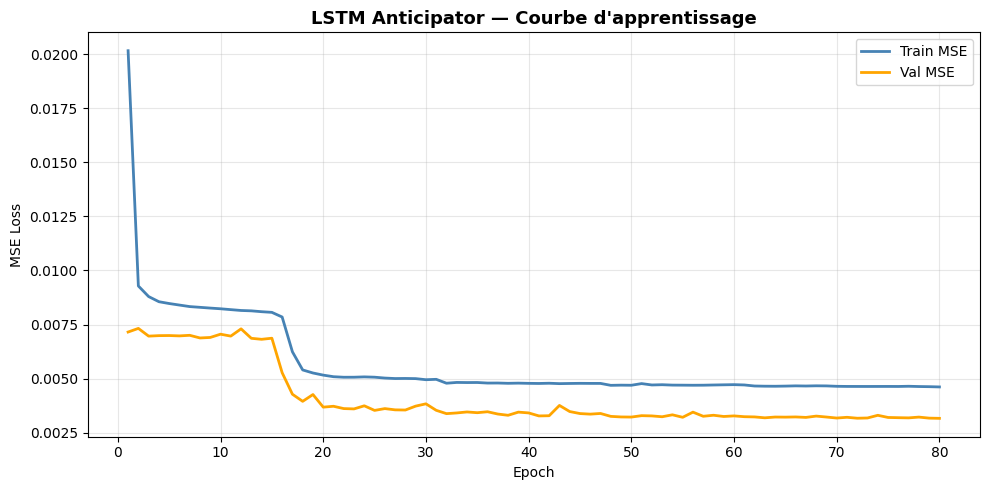

✅ Meilleur Val MSE : 0.003169
💾 Modèle sauvegardé : /content/lstm_anticipator_best.pth


In [ ]:
# ============================================================
# CELL 6 — Training LSTM sur CASIA-B
# ============================================================
from torch.utils.data import random_split

class GaitDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X)
        self.Y = torch.from_numpy(Y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.Y[i]

n_total  = len(X)
n_val    = int(0.2 * n_total)
n_tr     = n_total - n_val
dataset  = GaitDataset(X, Y)

tr_set, val_set = random_split(
    dataset, [n_tr, n_val],
    generator=torch.Generator().manual_seed(SEED))

tr_loader  = DataLoader(tr_set,  batch_size=256,
                        shuffle=True,  num_workers=2)
val_loader_lstm = DataLoader(val_set, batch_size=256,
                        shuffle=False, num_workers=2)

print(f"Train : {n_tr:,} | Val : {n_val:,}")

criterion_lstm = nn.MSELoss()
optimizer_lstm = torch.optim.Adam(
    model_lstm.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_lstm = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_lstm, mode='min', patience=5, factor=0.5)

EPOCHS   = 80
best_val = float('inf')
tr_hist  = []   # ← ajouté
val_hist = []   # ← ajouté

print(f"\n🚀 Entraînement LSTM — {EPOCHS} epochs\n")

for epoch in range(1, EPOCHS + 1):
    model_lstm.train()
    tr_loss = 0.0
    for xb, yb in tr_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer_lstm.zero_grad()
        loss = criterion_lstm(model_lstm(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(
            model_lstm.parameters(), 1.0)
        optimizer_lstm.step()
        tr_loss += loss.item()

    model_lstm.eval()
    vl_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader_lstm:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            vl_loss += criterion_lstm(
                model_lstm(xb), yb).item()

    tr_loss /= len(tr_loader)
    vl_loss /= len(val_loader_lstm)
    scheduler_lstm.step(vl_loss)

    tr_hist.append(tr_loss)    # ← ajouté
    val_hist.append(vl_loss)   # ← ajouté

    is_best = vl_loss < best_val
    if is_best:
        best_val = vl_loss
        torch.save(model_lstm.state_dict(),
                   '/content/lstm_anticipator_best.pth')

    if epoch % 10 == 0 or epoch == 1:
        lr = optimizer_lstm.param_groups[0]['lr']
        print(f"  Ep {epoch:03d} | "
              f"Train: {tr_loss:.5f} | "
              f"Val: {vl_loss:.5f} | "
              f"Best: {best_val:.5f} | "
              f"LR: {lr:.2e} "
              f"{'⭐' if is_best else ''}")

print(f"\n✅ Meilleur Val MSE : {best_val:.6f}")
print(f"💾 Modèle sauvegardé : /content/lstm_anticipator_best.pth")

# ── Courbes MSE ───────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(range(1, EPOCHS+1), tr_hist,
        color='steelblue', lw=2, label='Train MSE')
ax.plot(range(1, EPOCHS+1), val_hist,
        color='orange',    lw=2, label='Val MSE')

ax.set_title('LSTM Anticipator — Courbe d\'apprentissage',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/lstm_training.png',
            dpi=200, bbox_inches='tight')
plt.show()

print(f"✅ Meilleur Val MSE : {best_val:.6f}")
print(f"💾 Modèle sauvegardé : /content/lstm_anticipator_best.pth")


# visualisation

📊 MSE par pas de prédiction :
  t+ 62ms  MSE=0.00094  ████
  t+125ms  MSE=0.00084  ████
  t+187ms  MSE=0.00111  █████
  t+250ms  MSE=0.00152  ███████
  t+312ms  MSE=0.00122  ██████
  t+375ms  MSE=0.00168  ████████
  t+437ms  MSE=0.00174  ████████
  t+500ms  MSE=0.00196  █████████


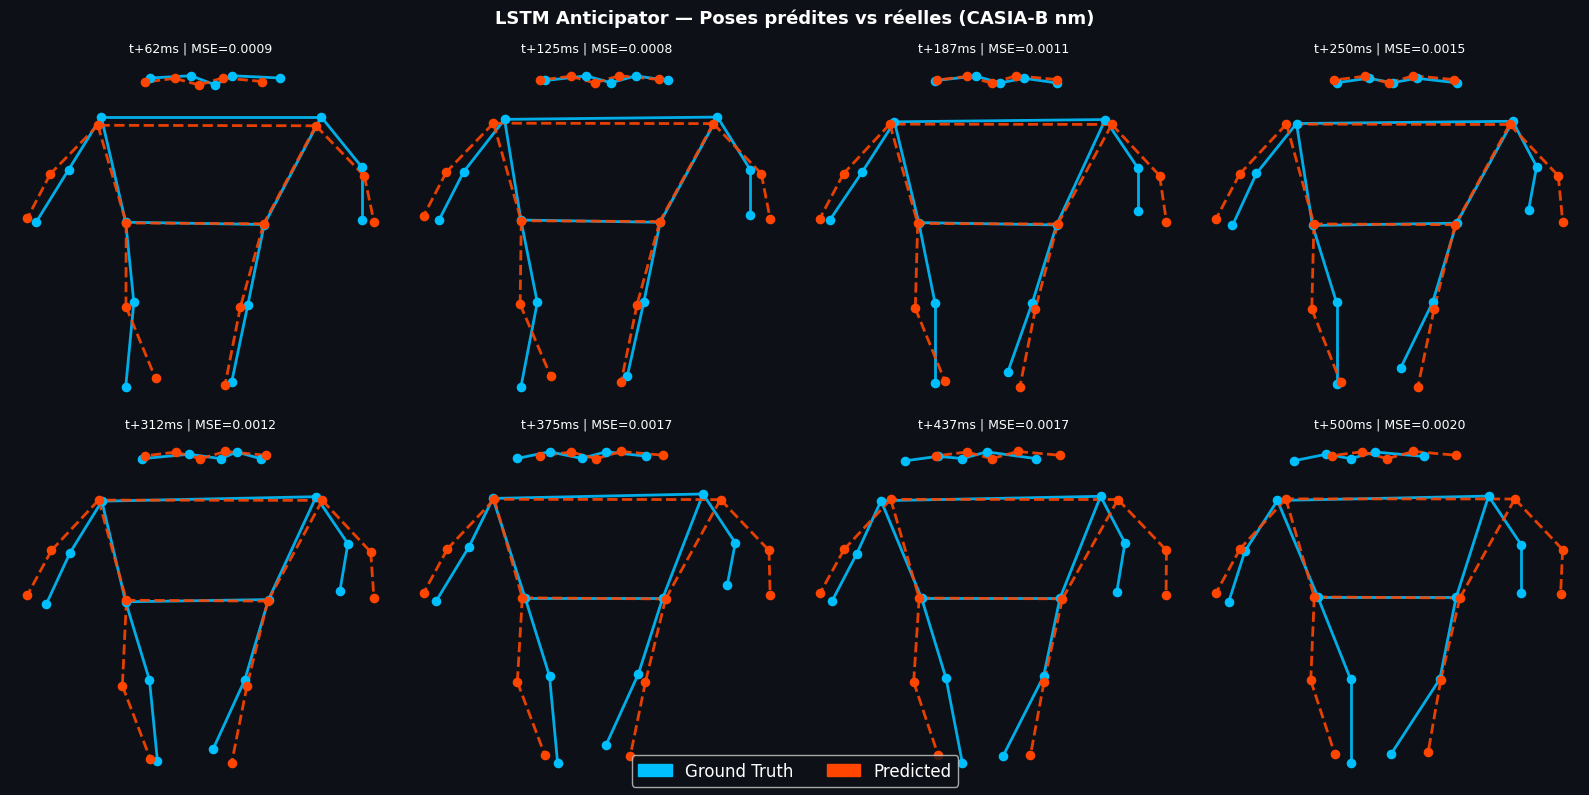

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# CELL — Visualisation poses prédites vs réelles
import matplotlib.patches as mpatches

# ── Fix : model → model_lstm ──────────────────────────────────
model_lstm.load_state_dict(
    torch.load('/content/lstm_anticipator_best.pth',
               map_location=DEVICE,
               weights_only=False))
model_lstm.eval()

x_samp = dataset[n_tr][0].unsqueeze(0).to(DEVICE)
y_true = dataset[n_tr][1].numpy()

with torch.no_grad():
    y_pred = model_lstm(x_samp).cpu().numpy()[0]

step_mse = [np.mean((y_pred[s] - y_true[s])**2)
            for s in range(PREDICT_STEPS)]

print("📊 MSE par pas de prédiction :")
for s, mse in enumerate(step_mse):
    ms  = (s + 1) * 1000 // FPS
    bar = '█' * int(mse * 5000)
    print(f"  t+{ms:3d}ms  MSE={mse:.5f}  {bar}")

def flat2kp(arr):
    return arr.reshape(17, 2)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.patch.set_facecolor('#0d1117')

for step in range(PREDICT_STEPS):
    ax = axes[step // 4][step % 4]
    ax.set_facecolor('#0d1117')
    ax.invert_yaxis()

    gt = flat2kp(y_true[step])
    pr = flat2kp(y_pred[step])

    for i, j in SKELETON_PAIRS:
        ax.plot([gt[i,0], gt[j,0]],
                [gt[i,1], gt[j,1]],
                color='deepskyblue', lw=2, alpha=0.9)
    ax.scatter(gt[:,0], gt[:,1],
               c='deepskyblue', s=35, zorder=5)

    for i, j in SKELETON_PAIRS:
        ax.plot([pr[i,0], pr[j,0]],
                [pr[i,1], pr[j,1]],
                color='orangered', lw=2, alpha=0.9,
                linestyle='--')
    ax.scatter(pr[:,0], pr[:,1],
               c='orangered', s=35, zorder=5)

    ms = (step + 1) * 1000 // FPS
    ax.set_title(f"t+{ms}ms | MSE={step_mse[step]:.4f}",
                 color='white', fontsize=9)
    ax.axis('off')

handles = [
    mpatches.Patch(color='deepskyblue',
                   label='Ground Truth'),
    mpatches.Patch(color='orangered',
                   label='Predicted')
]
fig.legend(handles=handles, loc='lower center', ncol=2,
           fontsize=12, facecolor='#0d1117',
           labelcolor='white')
fig.suptitle(
    "LSTM Anticipator — Poses prédites vs réelles "
    "(CASIA-B nm)",
    color='white', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/lstm_poses.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

from google.colab import files
files.download('/content/lstm_poses.png')

In [ ]:
# ============================================================
# CELL 7 — Download URFD
# ============================================================
urfd_path_raw = kagglehub.dataset_download(
    "mireillejabbour/fall-dataset")
print(f"✅ URFD path: {urfd_path_raw}")

✅ URFD path: /kaggle/input/datasets/mireillejabbour/fall-dataset


In [ ]:
# ============================================================
# CELL 8 — Fix MediaPipe
# ============================================================
!pip install mediapipe==0.10.14 -q
print("✅ Installation terminée")
print("⚠️  REDÉMARRE LE KERNEL : Runtime → Restart session")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 56.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 25.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.21.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
a2a-sdk 0.3.23 requires protobuf>=5.29.5, but you have protobuf 4.25.8 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
ydf 0.14.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 

In [ ]:
# ============================================================
# CELL 9 — Extraction Keypoints URFD (MediaPipe)
# ============================================================
import os, cv2, numpy as np, pickle
import mediapipe as mp
from pathlib import Path
from tqdm import tqdm

URFD_ROOT = Path(urfd_path_raw)
SAVE_PATH = Path("/content/urfd_keypoints")
SAVE_PATH.mkdir(exist_ok=True)

MP_INDICES = [0, 2, 1, 4, 3, 6, 5, 8, 7, 10, 9,
              12, 11, 14, 13, 16, 15]

from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request

MODEL_PATH = "/content/pose_landmarker_heavy.task"
if not os.path.exists(MODEL_PATH):
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/"
        "pose_landmarker/pose_landmarker_heavy/float16/"
        "latest/pose_landmarker_heavy.task",
        MODEL_PATH)
    print("✅ Modèle téléchargé")

base_options = python.BaseOptions(
    model_asset_path=MODEL_PATH)
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=False,
    num_poses=1,
    min_pose_detection_confidence=0.1,
    min_pose_presence_confidence=0.1,
    min_tracking_confidence=0.1,
    running_mode=vision.RunningMode.IMAGE
)
pose = vision.PoseLandmarker.create_from_options(options)
print("✅ PoseLandmarker initialisé")

def extract_keypoints_mediapipe(img_path):
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img_rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w     = img_rgb.shape[:2]
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB, data=img_rgb)
    results  = pose.detect(mp_image)
    if (not results.pose_landmarks
            or len(results.pose_landmarks) == 0):
        return None
    lm = results.pose_landmarks[0]
    kp = np.zeros((17, 3), dtype=np.float32)
    for coco_idx, mp_idx in enumerate(MP_INDICES):
        kp[coco_idx, 0] = lm[mp_idx].x * w
        kp[coco_idx, 1] = lm[mp_idx].y * h
        kp[coco_idx, 2] = getattr(
            lm[mp_idx], 'visibility', 1.0)
    return kp

def process_sequence(seq_dir, min_frames=5,
                     min_rate=0.5):
    frames    = sorted(seq_dir.glob("*.png"))
    if len(frames) == 0:
        return None
    keypoints = []
    for fp in frames:
        kp = extract_keypoints_mediapipe(fp)
        if kp is not None:
            keypoints.append(kp)
    det_rate = len(keypoints) / max(len(frames), 1)
    if len(keypoints) < min_frames or det_rate < min_rate:
        return None
    return np.stack(keypoints, axis=0)

def get_actual_dir(seq_dir):
    inner = [d for d in seq_dir.iterdir() if d.is_dir()]
    return inner[0] if len(inner) == 1 else seq_dir

# Falls
fall_root = (URFD_ROOT / "fall zip photo files"
             / "fall zip photo files")
fall_dirs      = sorted([d for d in fall_root.iterdir()
                         if d.is_dir()])
fall_sequences = {}
for seq_dir in tqdm(fall_dirs, desc="Falls"):
    kp = process_sequence(get_actual_dir(seq_dir))
    if kp is not None:
        fall_sequences[seq_dir.name] = kp

# ADLs
adl_root = (URFD_ROOT / "adl zip photo files"
            / "adl zip photo files")
adl_dirs      = sorted([d for d in adl_root.iterdir()
                        if d.is_dir()])
adl_sequences = {}
for seq_dir in tqdm(adl_dirs, desc="ADLs"):
    kp = process_sequence(get_actual_dir(seq_dir))
    if kp is not None:
        adl_sequences[seq_dir.name] = kp

with open(SAVE_PATH / "fall_keypoints.pkl", 'wb') as f:
    pickle.dump(fall_sequences, f)
with open(SAVE_PATH / "adl_keypoints.pkl", 'wb') as f:
    pickle.dump(adl_sequences, f)

print(f"\n✅ Falls : {len(fall_sequences)}")
print(f"✅ ADLs  : {len(adl_sequences)}")

2026-03-10 12:32:35.815491: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773145955.989005      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773145956.047542      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773145956.465383      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773145956.465426      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773145956.465429      55 computation_placer.cc:177] computation placer alr

✅ Modèle téléchargé
✅ PoseLandmarker initialisé


Falls:   0%|          | 0/118 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
ADLs: 100%|██████████| 80/80 [25:25<00:00, 19.07s/it]


✅ Falls : 110
✅ ADLs  : 66


In [ ]:
# ============================================================
# CELL 10 — Labellisation URFD
# ============================================================
import numpy as np, pickle
from pathlib import Path
from collections import Counter

SAVE_PATH  = Path("/content/urfd_keypoints")
PRE_FALL_F = 20
FALL_F     = 15

with open(SAVE_PATH / "fall_keypoints.pkl", 'rb') as f:
    fall_sequences = pickle.load(f)
with open(SAVE_PATH / "adl_keypoints.pkl", 'rb') as f:
    adl_sequences = pickle.load(f)

def label_fall_sequence(T):
    labels        = np.zeros(T, dtype=np.int64)
    fall_start    = max(0, T - FALL_F)
    prefall_start = max(0, T - FALL_F - PRE_FALL_F)
    labels[prefall_start:fall_start] = 1
    labels[fall_start:]              = 2
    return labels

labeled_data = []

for name, kp in fall_sequences.items():
    T = kp.shape[0]
    labeled_data.append({
        'keypoints': kp,
        'labels':    label_fall_sequence(T),
        'name':      name,
        'is_fall':   True
    })

for name, kp in adl_sequences.items():
    T = kp.shape[0]
    labeled_data.append({
        'keypoints': kp,
        'labels':    np.zeros(T, dtype=np.int64),
        'name':      name,
        'is_fall':   False
    })

all_labels = np.concatenate(
    [d['labels'] for d in labeled_data])
counts = Counter(all_labels.tolist())
total  = len(all_labels)

print(f"📊 Labels :")
print(f"  STABLE   : {counts[0]} ({100*counts[0]/total:.1f}%)")
print(f"  PRE-FALL : {counts[1]} ({100*counts[1]/total:.1f}%)")
print(f"  FALL     : {counts[2]} ({100*counts[2]/total:.1f}%)")

with open(SAVE_PATH / "labeled_data.pkl", 'wb') as f:
    pickle.dump(labeled_data, f)
print(f"✅ Saved: labeled_data.pkl")

📊 Labels :
  STABLE   : 16848 (81.4%)
  PRE-FALL : 2200 (10.6%)
  FALL     : 1650 (8.0%)
✅ Saved: labeled_data.pkl


In [ ]:
# ============================================================
# CELL 11 — Preprocessing URFD → X_urfd.npy (1:1:1)
# ============================================================
import numpy as np, pickle
from pathlib import Path
from collections import Counter

SAVE_PATH   = Path("/content/urfd_keypoints")
WINDOW_SIZE = 30
STRIDE      = 1

with open(SAVE_PATH / "labeled_data.pkl", 'rb') as f:
    labeled_data = pickle.load(f)

def extract_features_urfd(kp_seq):
    xy         = kp_seq[:, :, :2].copy()
    hip_center = (xy[:, 11, :] + xy[:, 12, :]) / 2.0
    rel        = xy - hip_center[:, np.newaxis, :]
    torso_h    = np.linalg.norm(
        xy[:, 0, :] - hip_center,
        axis=1, keepdims=True)
    torso_h    = np.where(torso_h < 1e-6, 1.0, torso_h)
    rel        = rel / torso_h[:, np.newaxis, :]
    return rel.reshape(len(kp_seq), -1).astype(np.float32)

X_all = {0: [], 1: [], 2: []}

for sample in labeled_data:
    kp   = sample['keypoints']
    labs = sample['labels']
    T    = len(kp)
    if T < WINDOW_SIZE + 1:
        continue
    feats = extract_features_urfd(kp)
    for start in range(0, T - WINDOW_SIZE):
        end       = start + WINDOW_SIZE
        win_label = int(labs[end - 1])
        X_all[win_label].append(feats[start:end])

n_min = min(len(X_all[0]),
            len(X_all[1]),
            len(X_all[2]))

np.random.seed(42)
X_balanced, Y_balanced = [], []
for cls in [0, 1, 2]:
    arr = np.array(X_all[cls])
    if len(arr) > n_min:
        idx = np.random.choice(len(arr), n_min,
                               replace=False)
        arr = arr[idx]
    X_balanced.append(arr)
    Y_balanced.append(
        np.full(len(arr), cls, dtype=np.int64))

X = np.concatenate(X_balanced, axis=0)
Y = np.concatenate(Y_balanced, axis=0)

shuffle_idx = np.random.permutation(len(X))
X = X[shuffle_idx]
Y = Y[shuffle_idx]

counts = Counter(Y.tolist())
print(f"✅ Dataset équilibré :")
print(f"   X shape  : {X.shape}")
print(f"   STABLE   : {counts[0]}")
print(f"   PRE-FALL : {counts[1]}")
print(f"   FALL     : {counts[2]}")

np.save(SAVE_PATH / "X_urfd.npy", X.astype(np.float32))
np.save(SAVE_PATH / "Y_urfd.npy", Y)
print(f"✅ Saved: X_urfd.npy, Y_urfd.npy")

✅ Dataset équilibré :
   X shape  : (4608, 30, 34)
   STABLE   : 1536
   PRE-FALL : 1536
   FALL     : 1536
✅ Saved: X_urfd.npy, Y_urfd.npy


In [ ]:
# ============================================================
# CELL 12 — Architecture DGNNClassifier
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F

N_JOINTS = 17

COCO_EDGES = [
    (0,1),(0,2),(1,3),(2,4),
    (5,6),(5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16)
]

def build_adjacency():
    A_src  = torch.zeros(N_JOINTS, N_JOINTS)
    A_tgt  = torch.zeros(N_JOINTS, N_JOINTS)
    A_self = torch.eye(N_JOINTS)
    for (i, j) in COCO_EDGES:
        A_src[i, j] = 1.0
        A_tgt[j, i] = 1.0
    def normalize(A):
        D = A.sum(dim=1, keepdim=True).clamp(min=1)
        return A / D
    return normalize(A_src), normalize(A_tgt), A_self


class DGNNLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.W_src  = nn.Linear(in_channels, out_channels,
                                bias=False)
        self.W_tgt  = nn.Linear(in_channels, out_channels,
                                bias=False)
        self.W_self = nn.Linear(in_channels, out_channels,
                                bias=False)
        self.bn  = nn.BatchNorm1d(out_channels)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x, A_src, A_tgt, A_self):
        B, N, C = x.shape
        h_src  = torch.bmm(
            A_src.unsqueeze(0).expand(B,-1,-1), x)
        h_tgt  = torch.bmm(
            A_tgt.unsqueeze(0).expand(B,-1,-1), x)
        h_self = torch.bmm(
            A_self.unsqueeze(0).expand(B,-1,-1), x)
        out = (self.W_src(h_src) + self.W_tgt(h_tgt)
               + self.W_self(h_self))
        out = self.bn(out.view(B*N, -1)).view(B, N, -1)
        return self.act(out)


class TemporalAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1)
        )
    def forward(self, x):
        scores  = self.attn(x)
        weights = torch.softmax(scores, dim=1)
        context = (weights * x).sum(dim=1)
        return context, weights


class DGNNClassifier(nn.Module):
    def __init__(self, T=30, n_classes=3, hidden=64):
        super().__init__()
        self.T          = T
        self.input_proj = nn.Linear(2, hidden)
        self.dgnn1      = DGNNLayer(hidden,   hidden)
        self.dgnn2      = DGNNLayer(hidden,   hidden*2)
        self.dgnn3      = DGNNLayer(hidden*2, hidden*2)
        gru_input       = N_JOINTS * hidden * 2
        self.gru        = nn.GRU(
            input_size    = gru_input,
            hidden_size   = 256,
            num_layers    = 2,
            batch_first   = True,
            dropout       = 0.3,
            bidirectional = True
        )
        self.temporal_attn = TemporalAttention(512)
        self.classifier = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, n_classes)
        )
        A_src, A_tgt, A_self = build_adjacency()
        self.register_buffer('A_src',  A_src)
        self.register_buffer('A_tgt',  A_tgt)
        self.register_buffer('A_self', A_self)

    def forward(self, x):
        B, T, _ = x.shape
        xg = x.view(B, T, N_JOINTS, 2)
        frame_features = []
        for t in range(T):
            xt = xg[:, t, :, :]
            xt = self.input_proj(xt)
            xt = self.dgnn1(xt, self.A_src,
                            self.A_tgt, self.A_self)
            xt = self.dgnn2(xt, self.A_src,
                            self.A_tgt, self.A_self)
            xt = self.dgnn3(xt, self.A_src,
                            self.A_tgt, self.A_self)
            xt = xt.view(B, -1)
            frame_features.append(xt)
        seq          = torch.stack(frame_features, dim=1)
        gru_out, _   = self.gru(seq)
        context, _   = self.temporal_attn(gru_out)
        return self.classifier(context)


model_dgnn = DGNNClassifier(
    T=30, n_classes=3, hidden=64).to(DEVICE)

n_params = sum(p.numel() for p in model_dgnn.parameters()
               if p.requires_grad)
print(f"✅ DGNNClassifier : {n_params:,} paramètres")
dummy = torch.zeros(4, 30, 34).to(DEVICE)
print(f"   Test : {dummy.shape} → "
      f"{model_dgnn(dummy).shape} ✓")

✅ DGNNClassifier : 5,304,388 paramètres
   Test : torch.Size([4, 30, 34]) → torch.Size([4, 3]) ✓


In [ ]:
# ============================================================
# CELL 13 — Transfert Poids LSTM → BiGRU du DGNN (FIXED)
# ============================================================
import torch

# ── Charger LSTM pré-entraîné ─────────────────────────────────
lstm_ckpt = LSTMAnticipator(
    input_size    = 34,
    hidden_size   = 256,
    num_layers    = 2,
    predict_steps = PREDICT_STEPS,
    dropout       = 0.3
).to(DEVICE)

lstm_ckpt.load_state_dict(
    torch.load('/content/lstm_anticipator_best.pth',
               map_location=DEVICE,
               weights_only=False)
)
lstm_ckpt.eval()
print("✅ LSTM chargé")

lstm_state = lstm_ckpt.lstm.state_dict()
gru_state  = model_dgnn.gru.state_dict()

# ── Inspecter les dimensions avant transfert ──────────────────
print("\n📊 Dimensions LSTM vs GRU :")
for key in lstm_state:
    lstm_shape = lstm_state[key].shape
    # Trouver la clé correspondante dans GRU
    gru_key = key  # même nom pour forward
    if gru_key in gru_state:
        gru_shape = gru_state[gru_key].shape
        print(f"  {key:20} | LSTM:{str(lstm_shape):20} "
              f"| GRU:{str(gru_shape):20}")

print("\n⏳ Transfert LSTM → GRU...")
print("   Seuls weight_hh et bias sont transférés")
print("   (weight_ih ignoré car input_size différent)\n")

transferred = 0
skipped     = 0

for layer in range(2):
    for weight_type in ['weight_hh', 'bias_ih', 'bias_hh']:
        # ⚠️ weight_ih IGNORÉ :
        # LSTM layer 0 : weight_ih shape (1024, 34)
        # GRU  layer 0 : weight_ih shape (768, N_JOINTS*hidden*2)
        # → input_size complètement différent ❌

        lstm_key = f"{weight_type}_l{layer}"
        if lstm_key not in lstm_state:
            skipped += 1
            continue

        lstm_w     = lstm_state[lstm_key]
        lstm_gates = lstm_w.shape[0] // 4  # 256 par gate

        for direction in ['fwd', 'bwd']:
            gru_key = (f"{weight_type}_l{layer}"
                       if direction == 'fwd'
                       else f"{weight_type}_l{layer}_reverse")

            if gru_key not in gru_state:
                skipped += 1
                continue

            gru_w    = gru_state[gru_key].clone()
            gru_size = gru_w.shape[0] // 3  # 256 par gate

            n = min(lstm_gates, gru_size)  # 256

            if weight_type == 'weight_hh':
                # LSTM : (4*256, 256) → GRU : (3*256, 256)
                # Même dimension colonne → transfert direct ✅
                lstm_cols = lstm_w.shape[1]  # 256
                gru_cols  = gru_w.shape[1]   # 256
                n_cols    = min(lstm_cols, gru_cols)

                for g in range(3):
                    gru_w[g*gru_size : g*gru_size+n,
                          :n_cols] = \
                        lstm_w[g*lstm_gates : g*lstm_gates+n,
                               :n_cols]

            elif 'bias' in weight_type:
                # LSTM : (4*256,) → GRU : (3*256,)
                # 1D → transfert simple ✅
                for g in range(3):
                    gru_w[g*gru_size : g*gru_size+n] = \
                        lstm_w[g*lstm_gates : g*lstm_gates+n]

            with torch.no_grad():
                gru_state[gru_key].copy_(gru_w)

            transferred += 1
            print(f"  ✅ L{layer} {weight_type:12} "
                  f"→ {direction} | "
                  f"LSTM:{lstm_w.shape} → GRU:{gru_w.shape}")

model_dgnn.gru.load_state_dict(gru_state)

print(f"\n✅ Transfert terminé")
print(f"   Transférés : {transferred} tenseurs")
print(f"   Ignorés    : {skipped} tenseurs "
      f"(weight_ih → input_size incompatible)")

# ── Vérification ─────────────────────────────────────────────
print("\n📊 Vérification weight_hh_l0 :")
lstm_sample = lstm_state['weight_hh_l0'][:3, :3]
dgnn_sample = model_dgnn.gru.state_dict()[
    'weight_hh_l0'][:3, :3]
match = torch.allclose(lstm_sample, dgnn_sample)
print(f"   LSTM : {lstm_sample.tolist()}")
print(f"   DGNN : {dgnn_sample.tolist()}")
print(f"   Match: {'✅ OUI' if match else '❌ NON'}")

print("\n📊 Vérification bias_hh_l0 :")
lstm_b = lstm_state['bias_hh_l0'][:5]
dgnn_b = model_dgnn.gru.state_dict()['bias_hh_l0'][:5]
match_b = torch.allclose(lstm_b, dgnn_b)
print(f"   LSTM : {lstm_b.tolist()}")
print(f"   DGNN : {dgnn_b.tolist()}")
print(f"   Match: {'✅ OUI' if match_b else '❌ NON'}")

print(f"\n📋 Ce qui a été transféré :")
print(f"   weight_hh → mémoire temporelle ✅")
print(f"   bias_ih   → biais input         ✅")
print(f"   bias_hh   → biais mémoire       ✅")
print(f"   weight_ih → ❌ ignoré "
      f"(input_size LSTM=34 ≠ GRU={N_JOINTS*64*2})")

print(f"\n📋 Stratégie Fine-Tuning :")
print(f"   Phase 1 (ep  1-50)  : GRU gelé")
print(f"   Phase 2 (ep 51-200) : tout dégelé")


✅ LSTM chargé

📊 Dimensions LSTM vs GRU :
  weight_ih_l0         | LSTM:torch.Size([1024, 34]) | GRU:torch.Size([768, 2176])
  weight_hh_l0         | LSTM:torch.Size([1024, 256]) | GRU:torch.Size([768, 256])
  bias_ih_l0           | LSTM:torch.Size([1024])   | GRU:torch.Size([768])   
  bias_hh_l0           | LSTM:torch.Size([1024])   | GRU:torch.Size([768])   
  weight_ih_l1         | LSTM:torch.Size([1024, 256]) | GRU:torch.Size([768, 512])
  weight_hh_l1         | LSTM:torch.Size([1024, 256]) | GRU:torch.Size([768, 256])
  bias_ih_l1           | LSTM:torch.Size([1024])   | GRU:torch.Size([768])   
  bias_hh_l1           | LSTM:torch.Size([1024])   | GRU:torch.Size([768])   

⏳ Transfert LSTM → GRU...
   Seuls weight_hh et bias sont transférés
   (weight_ih ignoré car input_size différent)

  ✅ L0 weight_hh    → fwd | LSTM:torch.Size([1024, 256]) → GRU:torch.Size([768, 256])
  ✅ L0 weight_hh    → bwd | LSTM:torch.Size([1024, 256]) → GRU:torch.Size([768, 256])
  ✅ L0 bias_ih      → fw

In [ ]:
# ============================================================
# CELL 14 — Fine-Tuning DGNN sur URFD (UPDATED)
# ============================================================
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

SAVE_PATH = Path("/content/urfd_keypoints")
DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED      = 42

X_urfd = np.load(SAVE_PATH / "X_urfd.npy")
Y_urfd = np.load(SAVE_PATH / "Y_urfd.npy")
print(f"X_urfd : {X_urfd.shape} | Y_urfd : {Y_urfd.shape}")

class URFDDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.Y[i]

dataset = URFDDataset(X_urfd, Y_urfd)
n_total = len(dataset)
n_val   = int(0.2 * n_total)
n_tr    = n_total - n_val

tr_set, val_set = random_split(
    dataset, [n_tr, n_val],
    generator=torch.Generator().manual_seed(SEED))

tr_loader  = DataLoader(tr_set,  batch_size=64,
                        shuffle=True)
val_loader = DataLoader(val_set, batch_size=64,
                        shuffle=False)

print(f"Train : {n_tr:,} | Val : {n_val:,}")

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets,
                             reduction='none')
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

criterion = FocalLoss(gamma=2.0)

print("\n🔒 Phase 1 : Geler BiGRU")
for name, param in model_dgnn.named_parameters():
    if 'gru' in name:
        param.requires_grad = False
    else:
        param.requires_grad = True

n_train  = sum(p.numel() for p in model_dgnn.parameters()
               if p.requires_grad)
n_frozen = sum(p.numel() for p in model_dgnn.parameters()
               if not p.requires_grad)
print(f"   Entraînables : {n_train:,}")
print(f"   Gelés        : {n_frozen:,}")

optimizer_p1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad,
           model_dgnn.parameters()),
    lr=1e-3, weight_decay=1e-4)
scheduler_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p1, T_max=50, eta_min=1e-5)

optimizer_p2 = torch.optim.AdamW(
    model_dgnn.parameters(),
    lr=5e-4, weight_decay=1e-4)
scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p2, T_max=150, eta_min=1e-6)

EPOCHS_P1 = 50
EPOCHS_P2 = 150
EPOCHS    = EPOCHS_P1 + EPOCHS_P2
best_f1   = 0.0
history   = []

print(f"\n🚀 Fine-Tuning DGNN — {EPOCHS} epochs")
print(f"   Phase 1 : ep   1-50  | GRU gelé    | lr=1e-3")
print(f"   Phase 2 : ep  51-200 | tout dégelé | lr=5e-4\n")

for epoch in range(1, EPOCHS + 1):

    if epoch == EPOCHS_P1 + 1:
        print("\n" + "="*55)
        print("🔓 Phase 2 : Dégeler BiGRU")
        print("="*55 + "\n")
        for param in model_dgnn.parameters():
            param.requires_grad = True
        n_train = sum(
            p.numel() for p in model_dgnn.parameters())
        print(f"   Tous dégelés : {n_train:,}\n")

    opt   = optimizer_p1 if epoch <= EPOCHS_P1 else optimizer_p2
    sch   = scheduler_p1 if epoch <= EPOCHS_P1 else scheduler_p2
    phase = 1            if epoch <= EPOCHS_P1 else 2

    # ── Train ─────────────────────────────────────────────────
    model_dgnn.train()
    total_loss   = 0.0
    train_correct = 0
    train_total   = 0

    for xb, yb in tr_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        logits = model_dgnn(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(
            model_dgnn.parameters(), 1.0)
        opt.step()
        total_loss    += loss.item()
        train_correct += (logits.argmax(dim=1) == yb).sum().item()
        train_total   += len(yb)
    sch.step()

    train_loss = total_loss / len(tr_loader)
    train_acc  = train_correct / train_total   # ← nouveau

    # ── Validation ────────────────────────────────────────────
    model_dgnn.eval()
    val_loss_total = 0.0
    all_preds, all_true = [], []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb   = xb.to(DEVICE), yb.to(DEVICE)
            logits   = model_dgnn(xb)
            val_loss_total += criterion(logits, yb).item()  # ← nouveau
            p = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(p)
            all_true.extend(yb.cpu().numpy())

    val_loss  = val_loss_total / len(val_loader)   # ← nouveau
    all_preds = np.array(all_preds)
    all_true  = np.array(all_true)
    val_acc   = np.mean(all_preds == all_true)
    val_f1    = f1_score(all_true, all_preds,
                         average='macro', zero_division=0)
    f1_all    = f1_score(all_true, all_preds,
                         average=None,    zero_division=0)
    f1_pre    = f1_all[1] if len(f1_all) > 1 else 0.0
    f1_fall   = f1_all[2] if len(f1_all) > 2 else 0.0

    is_best = val_f1 > best_f1
    if is_best:
        best_f1 = val_f1
        torch.save({
            'epoch':       epoch,
            'phase':       phase,
            'val_f1':      val_f1,
            'val_acc':     val_acc,
            'model_state': model_dgnn.state_dict()
        }, '/content/dgnn_finetuned_best.pth')

    history.append({
        'epoch':     epoch,
        'phase':     phase,
        'train_loss': train_loss,   # ← nouveau
        'val_loss':   val_loss,     # ← nouveau
        'train_acc':  train_acc,    # ← nouveau
        'val_acc':    val_acc,
        'val_f1':     val_f1,
        'f1_pre':     f1_pre,
        'f1_fall':    f1_fall
    })

    if epoch % 10 == 0 or epoch == 1:
        lr = opt.param_groups[0]['lr']
        print(f"Ep {epoch:03d} [P{phase}] | "
              f"TrLoss: {train_loss:.4f} | "
              f"ValLoss: {val_loss:.4f} | "
              f"TrAcc: {train_acc:.3f} | "
              f"ValAcc: {val_acc:.3f} | "
              f"F1: {val_f1:.3f} | "
              f"LR: {lr:.1e} "
              f"{'⭐' if is_best else ''}")

# ── Rapport final ─────────────────────────────────────────────
print("\n" + "="*55)
ckpt = torch.load('/content/dgnn_finetuned_best.pth',
                  map_location=DEVICE,
                  weights_only=False)
model_dgnn.load_state_dict(ckpt['model_state'])
print(f"✅ Best : epoch {ckpt['epoch']} "
      f"[Phase {ckpt['phase']}] | "
      f"F1={ckpt['val_f1']:.4f}")

model_dgnn.eval()
all_logits, all_true = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        all_logits.append(
            model_dgnn(xb.to(DEVICE)).cpu())
        all_true.extend(yb.tolist())

all_logits = torch.cat(all_logits)
all_probs  = torch.softmax(all_logits, dim=1).numpy()
all_true   = np.array(all_true)

print("\n  Threshold sweep :")
best_thresh, best_fall_f1 = 0.3, 0.0
for thresh in np.arange(0.10, 0.60, 0.05):
    preds_t = all_logits.argmax(dim=1).numpy().copy()
    preds_t[all_probs[:, 2] > thresh] = 2
    f1_t    = f1_score(all_true, preds_t,
                       average=None, zero_division=0)
    f1_mac  = f1_score(all_true, preds_t,
                       average='macro', zero_division=0)
    f1_fall = f1_t[2] if len(f1_t) > 2 else 0
    print(f"    thresh={thresh:.2f} | "
          f"F1_fall={f1_fall:.3f} | "
          f"F1_macro={f1_mac:.3f}")
    if f1_fall > best_fall_f1:
        best_fall_f1 = f1_fall
        best_thresh  = thresh

print(f"\n✅ Best threshold : {best_thresh:.2f} → "
      f"F1_fall={best_fall_f1:.3f}")

preds_final = all_logits.argmax(dim=1).numpy().copy()
preds_final[all_probs[:, 2] > best_thresh] = 2

print("\n📊 RAPPORT FINAL :")
print("="*55)
print(classification_report(
    all_true, preds_final,
    target_names=['STABLE', 'PRE-FALL', 'FALL']))

X_urfd : (4608, 30, 34) | Y_urfd : (4608,)
Train : 3,687 | Val : 921

🔒 Phase 1 : Geler BiGRU
   Entraînables : 383,044
   Gelés        : 4,921,344

🚀 Fine-Tuning DGNN — 200 epochs
   Phase 1 : ep   1-50  | GRU gelé    | lr=1e-3
   Phase 2 : ep  51-200 | tout dégelé | lr=5e-4

Ep 001 [P1] | TrLoss: 0.3703 | ValLoss: 0.2921 | TrAcc: 0.528 | ValAcc: 0.645 | F1: 0.613 | LR: 1.0e-03 ⭐
Ep 010 [P1] | TrLoss: 0.1286 | ValLoss: 0.1608 | TrAcc: 0.804 | ValAcc: 0.790 | F1: 0.787 | LR: 9.1e-04 
Ep 020 [P1] | TrLoss: 0.0775 | ValLoss: 0.1088 | TrAcc: 0.884 | ValAcc: 0.862 | F1: 0.859 | LR: 6.6e-04 
Ep 030 [P1] | TrLoss: 0.0461 | ValLoss: 0.1453 | TrAcc: 0.934 | ValAcc: 0.843 | F1: 0.835 | LR: 3.5e-04 
Ep 040 [P1] | TrLoss: 0.0294 | ValLoss: 0.0428 | TrAcc: 0.955 | ValAcc: 0.947 | F1: 0.946 | LR: 1.0e-04 ⭐
Ep 050 [P1] | TrLoss: 0.0221 | ValLoss: 0.0437 | TrAcc: 0.968 | ValAcc: 0.955 | F1: 0.955 | LR: 1.0e-05 

🔓 Phase 2 : Dégeler BiGRU

   Tous dégelés : 5,304,388

Ep 060 [P2] | TrLoss: 0.0632 | Va

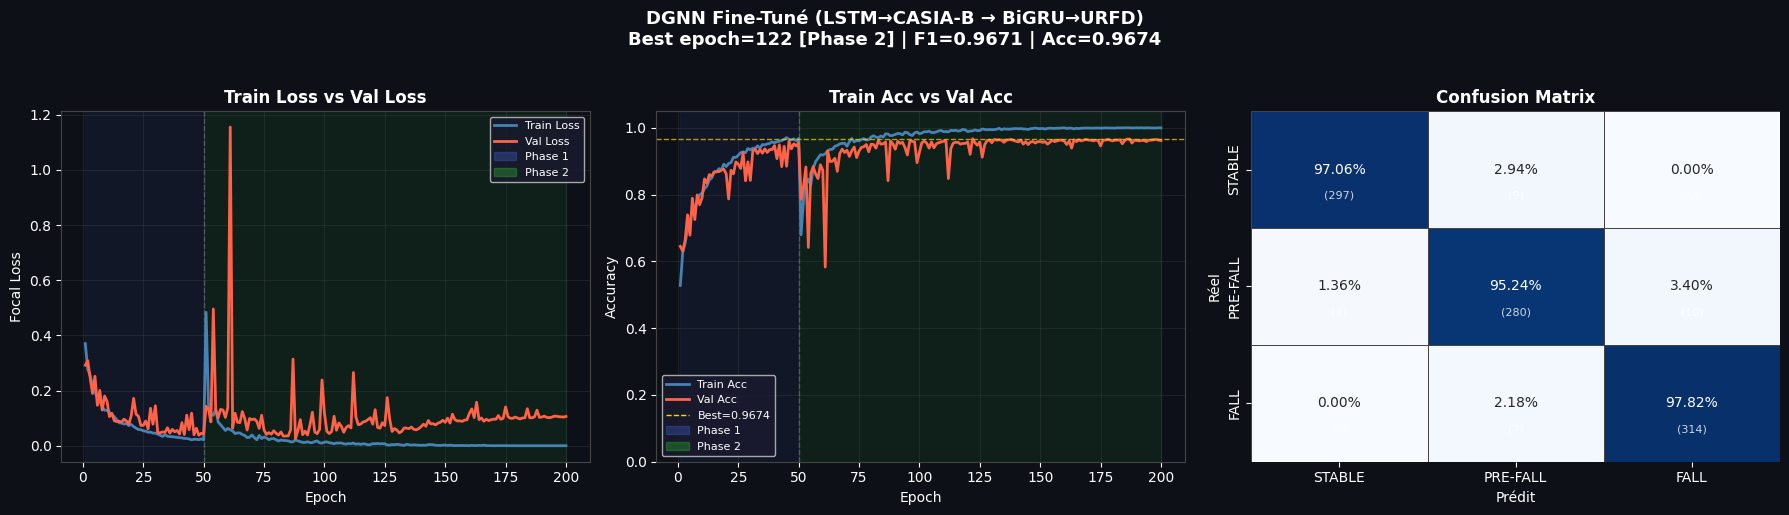


📊 RÉSULTATS FINAUX :
  Best epoch  : 122 [Phase 2]
  F1 macro    : 0.9671
  Accuracy    : 0.9674
  STABLE      : F1=0.9786
  PRE-FALL    : F1=0.9492
  FALL        : F1=0.9736

📊 Confusion Matrix :
                   STABLE   PRE-FALL       FALL
  STABLE              297          9          0
  PRE-FALL              4        280         10
  FALL                  0          7        314


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# CELL 15 — Loss + Accuracy + Confusion Matrix
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score
import torch

DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
CLASS_NAMES = ['STABLE', 'PRE-FALL', 'FALL']

epochs_     = [h['epoch']      for h in history]
train_loss_ = [h['train_loss'] for h in history]
val_loss_   = [h['val_loss']   for h in history]
train_acc_  = [h['train_acc']  for h in history]
val_acc_    = [h['val_acc']    for h in history]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0d1117')

for ax in axes:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444444')

# ── Graphe 1 : Train Loss vs Val Loss ────────────────────────
axes[0].axvspan(1,   50, alpha=0.08,
                color='royalblue')
axes[0].axvspan(50, 200, alpha=0.08,
                color='limegreen')
axes[0].axvline(x=50, color='gray',
                ls='--', alpha=0.5, lw=1)
axes[0].plot(epochs_, train_loss_,
             color='steelblue', lw=2,
             label='Train Loss')
axes[0].plot(epochs_, val_loss_,
             color='tomato', lw=2,
             label='Val Loss')
axes[0].set_title('Train Loss vs Val Loss',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Focal Loss')
axes[0].legend(fontsize=9,
               facecolor='#1a1a2e',
               labelcolor='white')
axes[0].grid(alpha=0.15, color='gray')

p1 = mpatches.Patch(color='royalblue',
                    alpha=0.3, label='Phase 1')
p2 = mpatches.Patch(color='limegreen',
                    alpha=0.3, label='Phase 2')
axes[0].legend(handles=[
    plt.Line2D([0],[0], color='steelblue',
               lw=2, label='Train Loss'),
    plt.Line2D([0],[0], color='tomato',
               lw=2, label='Val Loss'),
    p1, p2],
    fontsize=8,
    facecolor='#1a1a2e',
    labelcolor='white')

# ── Graphe 2 : Train Acc vs Val Acc ──────────────────────────
axes[1].axvspan(1,   50, alpha=0.08,
                color='royalblue')
axes[1].axvspan(50, 200, alpha=0.08,
                color='limegreen')
axes[1].axvline(x=50, color='gray',
                ls='--', alpha=0.5, lw=1)
axes[1].plot(epochs_, train_acc_,
             color='steelblue', lw=2,
             label='Train Accuracy')
axes[1].plot(epochs_, val_acc_,
             color='tomato', lw=2,
             label='Val Accuracy')
axes[1].axhline(y=ckpt['val_acc'],
                color='gold', ls='--',
                alpha=0.7, lw=1,
                label=f'Best={ckpt["val_acc"]:.4f}')
axes[1].set_title('Train Acc vs Val Acc',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend(handles=[
    plt.Line2D([0],[0], color='steelblue',
               lw=2, label='Train Acc'),
    plt.Line2D([0],[0], color='tomato',
               lw=2, label='Val Acc'),
    plt.Line2D([0],[0], color='gold',
               lw=1, ls='--',
               label=f'Best={ckpt["val_acc"]:.4f}'),
    p1, p2],
    fontsize=8,
    facecolor='#1a1a2e',
    labelcolor='white')
axes[1].grid(alpha=0.15, color='gray')

# ── Graphe 3 : Confusion Matrix ───────────────────────────────
model_dgnn.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        p = model_dgnn(xb.to(DEVICE)).argmax(
            dim=1).cpu().numpy()
        all_preds.extend(p)
        all_true.extend(yb.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

cm      = confusion_matrix(all_true, all_preds)
cm_norm = cm.astype(float) / cm.sum(
    axis=1, keepdims=True)

sns.heatmap(cm_norm,
            annot=True, fmt='.2%',
            cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            ax=axes[2],
            linewidths=0.5,
            linecolor='#444444',
            cbar=False)

for i in range(3):
    for j in range(3):
        axes[2].text(
            j + 0.5, i + 0.72,
            f'({cm[i,j]})',
            ha='center', va='center',
            color='white', fontsize=8,
            alpha=0.8)

axes[2].set_title('Confusion Matrix',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Prédit')
axes[2].set_ylabel('Réel')
axes[2].tick_params(colors='white')

# ── Titre global ──────────────────────────────────────────────
plt.suptitle(
    f'DGNN Fine-Tuné (LSTM→CASIA-B → BiGRU→URFD)\n'
    f'Best epoch={ckpt["epoch"]} '
    f'[Phase {ckpt["phase"]}] | '
    f'F1={ckpt["val_f1"]:.4f} | '
    f'Acc={ckpt["val_acc"]:.4f}',
    color='white', fontsize=13,
    fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('/content/dgnn_results.png',
            dpi=200, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

f1c = f1_score(all_true, all_preds,
               average=None, zero_division=0)
mac = f1_score(all_true, all_preds,
               average='macro', zero_division=0)

print(f"\n📊 RÉSULTATS FINAUX :")
print(f"{'='*50}")
print(f"  Best epoch  : {ckpt['epoch']} "
      f"[Phase {ckpt['phase']}]")
print(f"  F1 macro    : {mac:.4f}")
print(f"  Accuracy    : {ckpt['val_acc']:.4f}")
print(f"{'='*50}")
print(f"  STABLE      : F1={f1c[0]:.4f}")
print(f"  PRE-FALL    : F1={f1c[1]:.4f}")
print(f"  FALL        : F1={f1c[2]:.4f}")

print(f"\n📊 Confusion Matrix :")
print(f"  {'':12} {'STABLE':>10} "
      f"{'PRE-FALL':>10} {'FALL':>10}")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:12} {cm[i,0]:>10} "
          f"{cm[i,1]:>10} {cm[i,2]:>10}")

from google.colab import files
files.download('/content/dgnn_results.png')
